### Sentiment Analysis: Initial Data Exploration

The goal is to analyze sentiment. First, we need to load the dataset and understand its basic structure.

In [ ]:
import pandas as pd

# Load the Twitter_Data.csv file
try:
    df = pd.read_csv('/content/sample_data/Twitter_Data.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: Twitter_Data.csv not found. Please ensure it's in the /content/sample_data directory.")
    df = None

Dataset loaded successfully.


Now, let's look at the first few rows of the DataFrame to get a glimpse of the data, and then check its information (data types, non-null values).

In [ ]:
if df is not None:
    print("First 5 rows of the dataset:")
    display(df.head())
    print("\nDataFrame Information:")
    df.info()

First 5 rows of the dataset:


,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0



DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


Next, we will check for any missing values in the dataset. Missing data can affect our analysis and model training, so it's important to identify and handle them.

In [ ]:
if df is not None:
    print("Missing values per column:")
    display(df.isnull().sum())

Missing values per column:


,0
clean_text,4
category,7


Finally, let's examine the distribution of sentiment labels to understand the balance of positive, neutral, and negative sentiments in our dataset. This is crucial for evaluating potential class imbalance.

Sentiment distribution:


,count
category,
1.0,72250
0.0,55213
-1.0,35510


/tmp/ipykernel_4140/2993560291.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='category', data=df, palette='viridis')


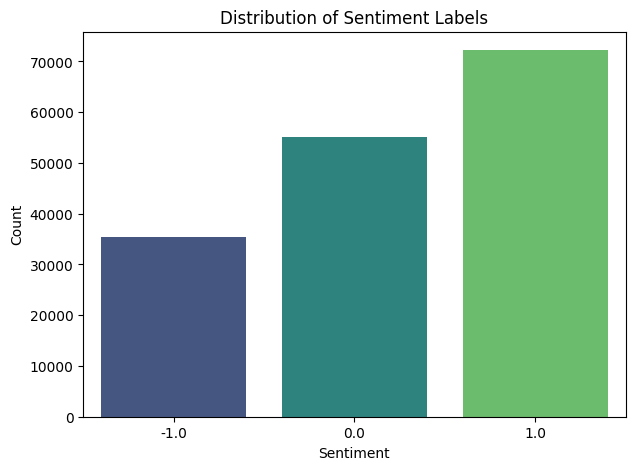

In [ ]:
if df is not None:
    print("Sentiment distribution:")
    display(df['category'].value_counts())

    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(7, 5))
    sns.countplot(x='category', data=df, palette='viridis')
    plt.title('Distribution of Sentiment Labels')
    plt.xlabel('Sentiment')
    plt.ylabel('Count')
    plt.show()

### Data Preprocessing: Handling Missing Values

Before proceeding with text preprocessing, it's essential to handle any missing values in our dataset. We observed earlier that there are a few missing entries in `clean_text` and `category` columns. Given their small number, we will drop these rows to maintain data quality.

In [ ]:
if df is not None:
    # Drop rows with any missing values
    df_cleaned = df.dropna().reset_index(drop=True)
    print(f"Original DataFrame shape: {df.shape}")
    print(f"DataFrame shape after dropping missing values: {df_cleaned.shape}")
    print("\nMissing values after dropping:")
    display(df_cleaned.isnull().sum())

    # Update df to be the cleaned version for subsequent steps
    df = df_cleaned

Original DataFrame shape: (162980, 2)
DataFrame shape after dropping missing values: (162969, 2)

Missing values after dropping:


,0
clean_text,0
category,0


### Data Preprocessing: Text Cleaning

With missing values handled, the next critical step is to clean the `clean_text` column. This involves several natural language processing (NLP) techniques to prepare the text for sentiment analysis models. We will perform the following operations:

1.  **Convert to Lowercase**: Normalize text to a consistent case.
2.  **Remove Punctuation**: Get rid of special characters that don't contribute to sentiment.
3.  **Remove Numbers**: Numbers are generally not relevant for sentiment analysis.
4.  **Remove Special Characters**: Eliminate any remaining non-alphanumeric characters.
5.  **Remove Stop Words**: Eliminate common words (like 'the', 'is', 'a') that carry little to no sentiment.
6.  **Lemmatization**: Reduce words to their base or root form to reduce vocabulary size and improve model accuracy.

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str): # Ensure input is string
        return ""
    # 1. Convert to Lowercase
    text = text.lower()
    # 2. Remove Punctuation and Numbers
    text = re.sub(r'[^a-z]', ' ', text) # Keep only letters a-z
    # 3. Tokenization and Remove Stop Words, Lemmatization
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

if df is not None:
    print("Applying text preprocessing to 'clean_text' column...")
    # Apply the preprocessing function
    df['processed_text'] = df['clean_text'].apply(preprocess_text)
    print("Text preprocessing complete.")
    print("\nFirst 5 rows with processed text:")
    display(df[['clean_text', 'processed_text', 'category']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Applying text preprocessing to 'clean_text' column...
Text preprocessing complete.

First 5 rows with processed text:


,clean_text,processed_text,category
0,when modi promised “minimum government maximum...,modi promised minimum government maximum gover...,-1.0
1,talk all the nonsense and continue all the dra...,talk nonsense continue drama vote modi,0.0
2,what did just say vote for modi welcome bjp t...,say vote modi welcome bjp told rahul main camp...,1.0
3,asking his supporters prefix chowkidar their n...,asking supporter prefix chowkidar name modi gr...,1.0
4,answer who among these the most powerful world...,answer among powerful world leader today trump...,1.0


### Feature Engineering: TF-IDF Vectorization

Now that the text data has been cleaned and preprocessed, the next step is to convert these text documents into numerical feature vectors that can be used by machine learning models. We will use the TF-IDF (Term Frequency-Inverse Document Frequency) vectorizer, which reflects the importance of a word in a document relative to its importance across all documents.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

if df is not None:
    print("Initializing TF-IDF Vectorizer and transforming text data...")
    # Initialize TfidfVectorizer
    # We'll use max_features to limit the number of features and reduce dimensionality
    tfidf_vectorizer = TfidfVectorizer(max_features=5000)

    # Fit and transform the processed text data
    X = tfidf_vectorizer.fit_transform(df['processed_text'])

    print(f"Shape of TF-IDF feature matrix: {X.shape}")
    print("TF-IDF vectorization complete.")

Initializing TF-IDF Vectorizer and transforming text data...
Shape of TF-IDF feature matrix: (162969, 5000)
TF-IDF vectorization complete.


### Model Training: Logistic Regression

With the text data transformed into numerical features, we can now train a machine learning model for sentiment classification. We will use Logistic Regression, a simple yet effective algorithm for binary and multi-class classification tasks. We will split the data into training and testing sets to evaluate the model's performance.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

if df is not None and 'category' in df.columns:
    print("Splitting data into training and testing sets...")
    # Define features (X) and target (y)
    y = df['category']

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

    print("\nTraining Logistic Regression model...")
    # Initialize and train the Logistic Regression model
    log_reg_model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
    log_reg_model.fit(X_train, y_train)
    print("Model training complete.")

    print("\nEvaluating model performance...")
    # Make predictions on the test set
    y_pred = log_reg_model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(report)
else:
    print("DataFrame 'df' is None or 'category' column is missing. Cannot proceed with model training.")

Splitting data into training and testing sets...
X_train shape: (130375, 5000), y_train shape: (130375,)
X_test shape: (32594, 5000), y_test shape: (32594,)

Training Logistic Regression model...
Model training complete.

Evaluating model performance...
Accuracy: 0.8765
Classification Report:
              precision    recall  f1-score   support

        -1.0       0.87      0.74      0.80      7102
         0.0       0.84      0.96      0.90     11042
         1.0       0.91      0.88      0.90     14450

    accuracy                           0.88     32594
   macro avg       0.87      0.86      0.86     32594
weighted avg       0.88      0.88      0.87     32594



### Model Evaluation: Confusion Matrix Visualization

To get a more detailed understanding of our model's performance, let's visualize the confusion matrix. This matrix will help us see the number of correct and incorrect predictions made by our model for each sentiment category, providing insights into specific types of errors.

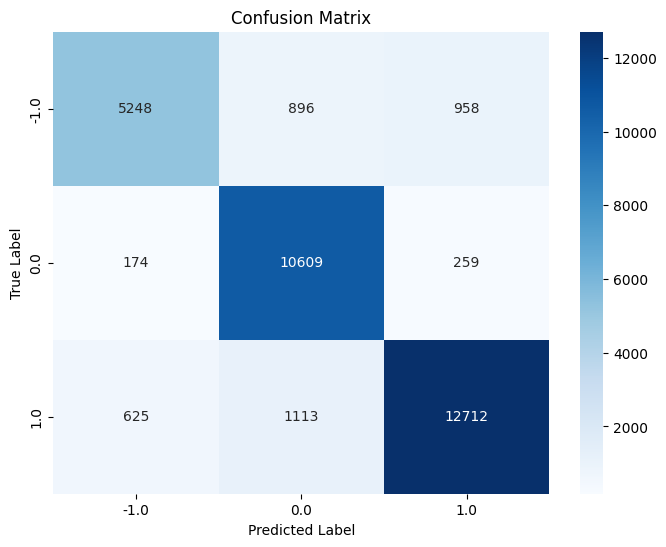

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

if df is not None and 'category' in df.columns:
    # Generate the confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Get unique class labels for the plot
    class_labels = sorted(y_test.unique())

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
else:
    print("DataFrame 'df' is None or 'category' column is missing. Cannot generate confusion matrix.")